In [4]:
import numpy as np
import pandas as pd
from collections import Counter
import time

def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def cosine_distance(a, b):
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-10
    return 1 - (np.dot(a, b) / denom)

def jaccard_distance(a, b):
    return 1 - (np.sum(np.minimum(a, b)) / (np.sum(np.maximum(a, b)) + 1e-10))



class KMeansCustom:
    def __init__(self, k=3, max_iter=100, tol=1e-4, distance="euclidean"):
        self.k = k
        self.max_iter = max_iter
        self.tol = tol
        self.distance_type = distance

    def _distance(self, a, b):
        if self.distance_type == "euclidean":
            return euclidean_distance(a, b)
        elif self.distance_type == "cosine":
            return cosine_distance(a, b)
        elif self.distance_type == "jaccard":
            return jaccard_distance(a, b)

    def fit(self, X):
        n_samples, n_features = X.shape

        # Random initialization
        random_idx = np.random.choice(n_samples, self.k, replace=False)
        self.centroids = X[random_idx]

        for iteration in range(self.max_iter):
            clusters = [[] for _ in range(self.k)]

            # Assign points to nearest centroid
            for idx, point in enumerate(X):
                distances = [self._distance(point, c) for c in self.centroids]
                cluster_idx = np.argmin(distances)
                clusters[cluster_idx].append(idx)

            new_centroids = np.zeros((self.k, n_features))

            for i, cluster in enumerate(clusters):
                if len(cluster) > 0:
                    new_centroids[i] = np.mean(X[cluster], axis=0)
                else:
                    new_centroids[i] = self.centroids[i]

            # Stop if centroids do not change
            if np.all(np.abs(new_centroids - self.centroids) < self.tol):
                break

            self.centroids = new_centroids

        self.labels_ = self._get_labels(X)
        return self

    def _get_labels(self, X):
        labels = []
        for point in X:
            distances = [self._distance(point, c) for c in self.centroids]
            labels.append(np.argmin(distances))
        return np.array(labels)



def compute_sse(X, labels, centroids, distance_type):
    sse = 0
    for i in range(len(X)):
        centroid = centroids[labels[i]]

        if distance_type == "euclidean":
            dist = np.sum((X[i] - centroid) ** 2)

        elif distance_type == "cosine":
            denom = (np.linalg.norm(X[i]) * np.linalg.norm(centroid)) + 1e-10
            dist = 1 - (np.dot(X[i], centroid) / denom)

        elif distance_type == "jaccard":
            dist = 1 - (np.sum(np.minimum(X[i], centroid)) /
                        (np.sum(np.maximum(X[i], centroid)) + 1e-10))

        sse += dist

    return sse


def compute_accuracy(true_labels, cluster_labels):
    label_map = {}

    for cluster in np.unique(cluster_labels):
        indices = np.where(cluster_labels == cluster)[0]
        majority = Counter(true_labels[indices]).most_common(1)[0][0]
        label_map[cluster] = majority

    predicted = np.array([label_map[c] for c in cluster_labels])
    accuracy = np.sum(predicted == true_labels) / len(true_labels)
    return accuracy


def run_kmeans_experiment(X, y, k):
    methods = ["euclidean", "cosine", "jaccard"]
    results = {}

    for method in methods:
        print(f"\nRunning KMeans with {method}")

        start = time.time()

        model = KMeansCustom(k=k, distance=method)
        model.fit(X)

        end = time.time()

        sse = compute_sse(X, model.labels_, model.centroids, method)
        acc = compute_accuracy(y, model.labels_)

        results[method] = {
            "SSE": sse,
            "Accuracy": acc,
            "Time": end - start
        }

        print(f"SSE: {sse:.4f}, Accuracy: {acc:.4f}, Time: {end-start:.2f}s")

    return results


df = pd.read_csv("/Users/varunreddy/Downloads/kmeans_data/data.csv")

print(df.head())

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

k = len(np.unique(y))


results = run_kmeans_experiment(X, y, k)

print("\nFinal Results:")
print(results)

   0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  ...  0.658  0.659  0.660  \
0  0    0    0    0    0    0    0    0    0    0  ...      0      0      0   
1  0    0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  0    0    0    0    0    0    0    0    0    0  ...      0      0      0   
3  0    0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  0    0    0    0    0    0    0    0    0    0  ...      0      0      0   

   0.661  0.662  0.663  0.664  0.665  0.666  0.667  
0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0  

[5 rows x 784 columns]

Running KMeans with euclidean
SSE: 34361687572.7277, Accuracy: 1.0000, Time: 0.24s

Running KMeans with cosine
SSE: 3610.6590, Accuracy: 1.0000, Time: 0.26s

Running KMeans with jacc

Dataset shape: (100004, 4)
   userId  movieId  rating   timestamp
0       1       31     2.5  1260759144
1       1     1029     3.0  1260759179
2       1     1061     3.0  1260759182
3       1     1129     2.0  1260759185
4       1     1172     4.0  1260759205

=== Q(b): Basic Models ===

Running User-CF
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9753  0.9677  0.9709  0.9670  0.9671  0.9696  0.0032  
MAE (testset)     0.7479  0.7426  0.7452  0.7422  0.7459  0.7447  0.0021  
Fit time          0.03    0.04    0.04    0.0

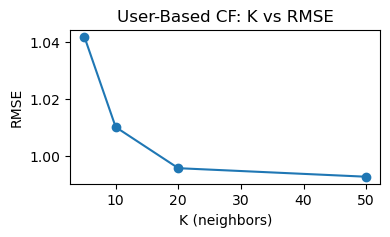


=== Q(f): K vs RMSE (Item-based) ===
Running Item-CF for k=5
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Running Item-CF for k=10
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Running Item-CF for k=20
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done compu

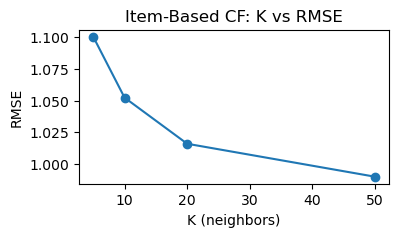


=== Q(g): Best K ===
Best K (User-based): 50
Best K (Item-based): 50

=== FINAL SUMMARY ===

Basic Models:
               RMSE       MAE
User-CF    0.969576  0.744746
Item-CF    0.935008  0.720951
PMF (SVD)  0.896922  0.691091

Similarity Comparison:
             RMSE
cosine   0.993774
msd      0.967365
pearson  0.996880

K vs RMSE (User-based):
    K      RMSE
0   5  1.041978
1  10  1.010209
2  20  0.995762
3  50  0.992762

K vs RMSE (Item-based):
    K      RMSE
0   5  1.100189
1  10  1.052268
2  20  1.015965
3  50  0.990028


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from surprise import Dataset, Reader, KNNBasic, SVD
from surprise.model_selection import cross_validate


ratings = pd.read_csv("/Users/varunreddy/Downloads/archive/ratings_small.csv")

print("Dataset shape:", ratings.shape)
print(ratings.head())

# Convert to Surprise format
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)


print("\n=== Q(b): Basic Models ===")

models = {
    "User-CF": KNNBasic(sim_options={'user_based': True}),
    "Item-CF": KNNBasic(sim_options={'user_based': False}),
    "PMF (SVD)": SVD()
}

basic_results = {}

for name, model in models.items():
    print(f"\nRunning {name}")
    cv = cross_validate(model, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

    basic_results[name] = {
        "RMSE": np.mean(cv['test_rmse']),
        "MAE": np.mean(cv['test_mae'])
    }

print("\nBasic Results Summary:")
print(pd.DataFrame(basic_results).T)



print("\n=== Q(c,d): Model Comparison ===")
for model, vals in basic_results.items():
    print(f"{model}: RMSE={vals['RMSE']:.4f}, MAE={vals['MAE']:.4f}")



print("\n=== Q(e): Similarity Metrics ===")

similarities = ['cosine', 'msd', 'pearson']
sim_results = {}

for sim in similarities:
    print(f"\nTesting similarity: {sim}")

    model = KNNBasic(sim_options={
        'name': sim,
        'user_based': True
    })

    cv = cross_validate(model, data, measures=['RMSE'], cv=5, verbose=False)
    sim_results[sim] = np.mean(cv['test_rmse'])

print("\nSimilarity Results:")
print(pd.DataFrame(sim_results, index=["RMSE"]).T)



print("\n=== Q(f): K vs RMSE (User-based) ===")

k_values = [5, 10, 20, 50]
rmse_user = []

for k in k_values:
    print(f"Running User-CF for k={k}")

    model = KNNBasic(
        k=k,
        sim_options={'name': 'cosine', 'user_based': True}
    )

    cv = cross_validate(model, data, measures=['RMSE'], cv=5, verbose=False)
    rmse_user.append(np.mean(cv['test_rmse']))


plt.figure(figsize=(4,2))
plt.plot(k_values, rmse_user, marker='o')
plt.xlabel("K (neighbors)")
plt.ylabel("RMSE")
plt.title("User-Based CF: K vs RMSE")
plt.savefig("user_cf_plot.png", bbox_inches='tight')
plt.show()



print("\n=== Q(f): K vs RMSE (Item-based) ===")

rmse_item = []

for k in k_values:
    print(f"Running Item-CF for k={k}")

    model = KNNBasic(
        k=k,
        sim_options={'name': 'cosine', 'user_based': False}
    )

    cv = cross_validate(model, data, measures=['RMSE'], cv=5, verbose=False)
    rmse_item.append(np.mean(cv['test_rmse']))


plt.figure(figsize=(4,2))
plt.plot(k_values, rmse_item, marker='o')
plt.xlabel("K (neighbors)")
plt.ylabel("RMSE")
plt.title("Item-Based CF: K vs RMSE")
plt.savefig("item_cf_plot.png", bbox_inches='tight')
plt.show()



best_k_user = k_values[np.argmin(rmse_user)]
best_k_item = k_values[np.argmin(rmse_item)]

print("\n=== Q(g): Best K ===")
print("Best K (User-based):", best_k_user)
print("Best K (Item-based):", best_k_item)



print("\n=== FINAL SUMMARY ===")

print("\nBasic Models:")
print(pd.DataFrame(basic_results).T)

print("\nSimilarity Comparison:")
print(pd.DataFrame(sim_results, index=["RMSE"]).T)

print("\nK vs RMSE (User-based):")
print(pd.DataFrame({"K": k_values, "RMSE": rmse_user}))

print("\nK vs RMSE (Item-based):")
print(pd.DataFrame({"K": k_values, "RMSE": rmse_item}))